# 03 — Análisis Espacial
**Objetivo:** Visualizar la distribución espacial por banco, cargar el área de proyección DXF y explorar la grilla de mallas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from pathlib import Path
import ezdxf

DATA_PATH = Path('../Documentacion/Referencias/Datos Demo')
BH_PATH   = DATA_PATH / 'Data_BH'

collar = pd.read_csv(BH_PATH / 'collar.csv')
assay  = pd.read_csv(BH_PATH / 'assay.csv')

df = collar.merge(assay[['HOLEID', 'CU']], on='HOLEID', how='left')
print(f'Dataset: {df.shape}')

Dataset: (18521, 18)


## 1. Grilla de mallas (EAST × NORTH) por banco

In [2]:
print('Spacing ESTE:')
print(collar['EAST'].sort_values().diff().value_counts().head(5))
print('\nSpacing NORTE:')
print(collar['NORTH'].sort_values().diff().value_counts().head(5))
print('\nMallas únicas por banco:')
print(collar.groupby('BANCO')['MALLA'].nunique().sort_index())

Spacing ESTE:
EAST
0.00    3020
0.03    2229
0.01    2197
0.02    1812
0.04     979
Name: count, dtype: int64

Spacing NORTE:
NORTH
0.00    10815
0.01      914
0.02      708
0.03      505
0.05      412
Name: count, dtype: int64

Mallas únicas por banco:
BANCO
4450     4
4465    38
4480    57
4495     1
Name: MALLA, dtype: int64


## 2. Mapa de calor de ley CU por banco

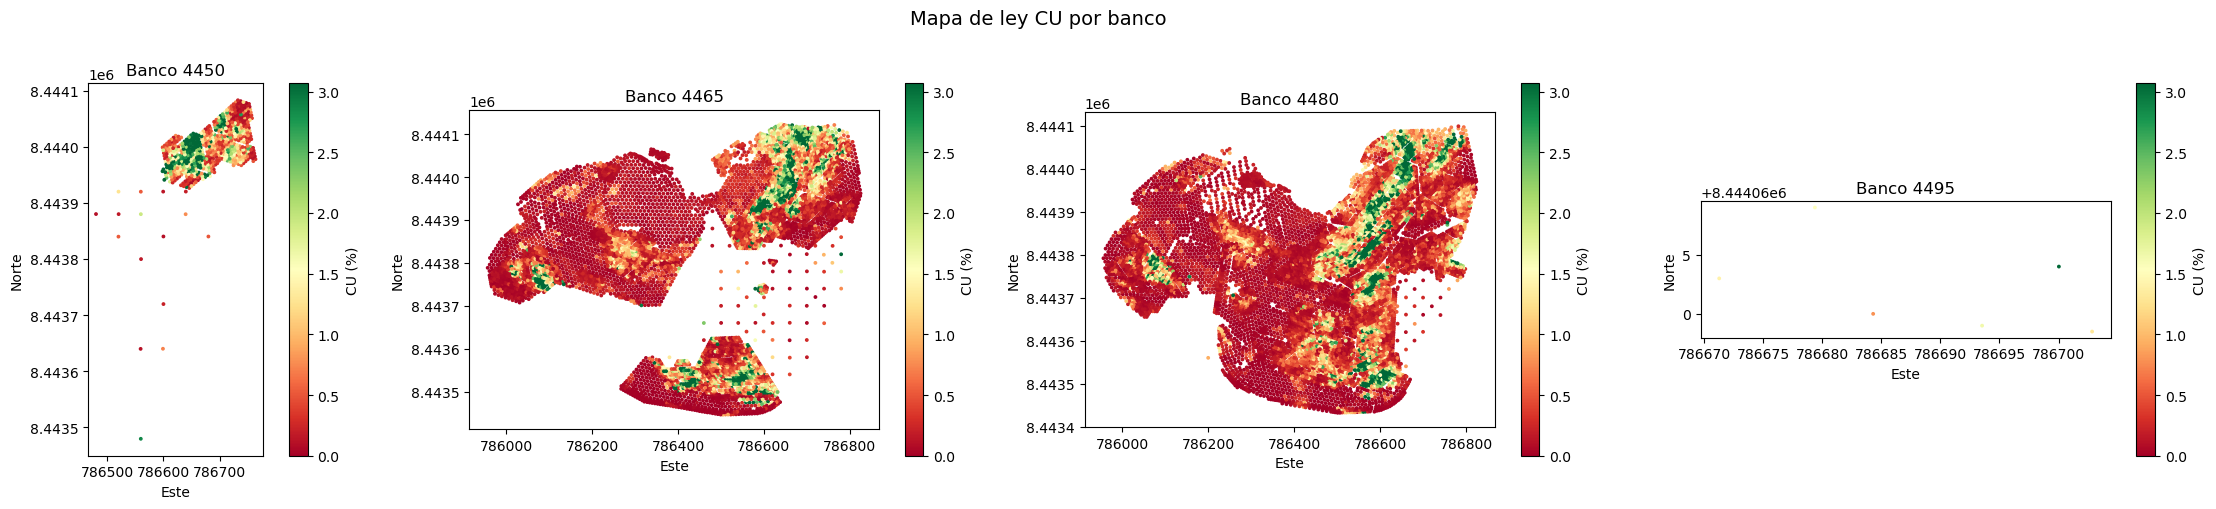

In [3]:
bancos = sorted(df['BANCO'].dropna().unique())
n = len(bancos)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
axes = axes.flatten() if n > 1 else [axes]

for i, banco in enumerate(bancos):
    sub = df[(df['BANCO'] == banco) & df['CU'].notna()]
    sc = axes[i].scatter(sub['EAST'], sub['NORTH'], c=sub['CU'],
                         cmap='RdYlGn', s=3, vmin=0, vmax=df['CU'].quantile(0.95))
    plt.colorbar(sc, ax=axes[i], label='CU (%)')
    axes[i].set_title(f'Banco {int(banco)}')
    axes[i].set_aspect('equal')
    axes[i].set_xlabel('Este')
    axes[i].set_ylabel('Norte')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Mapa de ley CU por banco', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Cargar área de proyección (DXF)

In [4]:
dxf_path = DATA_PATH / 'area_proyeccion.dxf'
doc = ezdxf.readfile(str(dxf_path))
msp = doc.modelspace()

print('Entidades DXF:')
entity_types = {}
for ent in msp:
    t = ent.dxftype()
    entity_types[t] = entity_types.get(t, 0) + 1
print(entity_types)

Entidades DXF:
{'POLYLINE': 1}


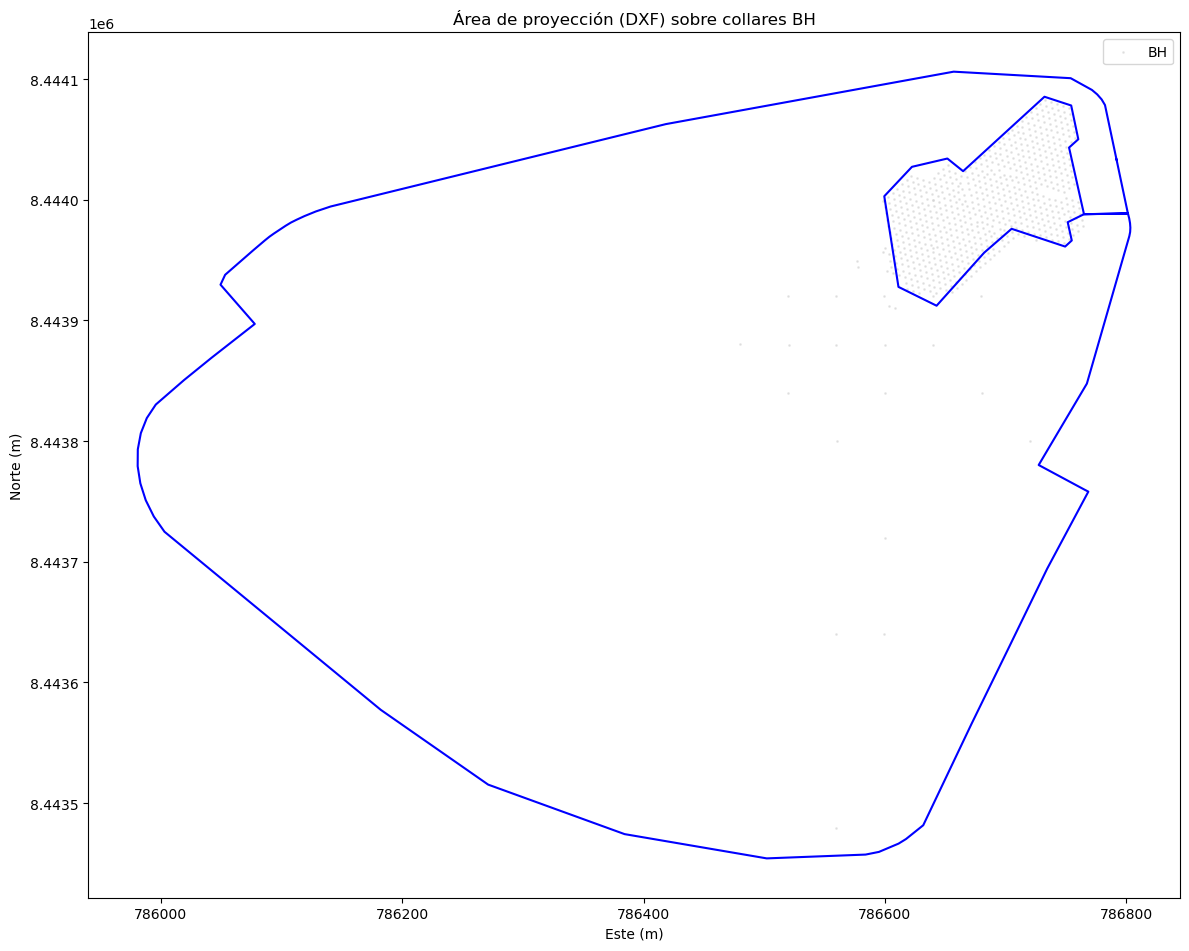

In [5]:
fig, ax = plt.subplots(figsize=(12, 10))

# BH collares como fondo
banco_base = df[df['BANCO'] == df['BANCO'].min()]
ax.scatter(banco_base['EAST'], banco_base['NORTH'], s=1, color='lightgray', alpha=0.5, label='BH')

# Polígonos DXF
for ent in msp:
    if ent.dxftype() == 'LWPOLYLINE':
        pts = np.array(list(ent.get_points()))[:, :2]
        ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=1.5)
    elif ent.dxftype() == 'POLYLINE':
        pts = np.array([[v.dxf.location.x, v.dxf.location.y] for v in ent.vertices])
        ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=1.5)

ax.set_aspect('equal')
ax.set_xlabel('Este (m)')
ax.set_ylabel('Norte (m)')
ax.set_title('Área de proyección (DXF) sobre collares BH')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Estadísticas de cobertura por banco

In [6]:
stats = df.groupby('BANCO').agg(
    n_pozos=('HOLEID', 'count'),
    n_con_cu=('CU', 'count'),
    cu_mean=('CU', 'mean'),
    cu_std=('CU', 'std'),
    cu_p50=('CU', lambda x: x.quantile(0.5)),
    cu_p95=('CU', lambda x: x.quantile(0.95)),
    east_min=('EAST', 'min'), east_max=('EAST', 'max'),
    north_min=('NORTH', 'min'), north_max=('NORTH', 'max'),
).round(3)

stats['pct_con_cu'] = (stats['n_con_cu'] / stats['n_pozos'] * 100).round(1)
print(stats[['n_pozos', 'n_con_cu', 'pct_con_cu', 'cu_mean', 'cu_std', 'cu_p50', 'cu_p95']].to_string())

       n_pozos  n_con_cu  pct_con_cu  cu_mean  cu_std  cu_p50  cu_p95
BANCO                                                                
4450       700       624        89.1    1.441   1.337   1.026   4.135
4465      7190      6789        94.4    0.775   1.211   0.295   3.171
4480     10623      9676        91.1    0.687   1.089   0.273   2.857
4495         8         6        75.0    1.900   1.409   1.478   3.944
